In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist


In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

In [3]:
# Normalize values (0-255 → 0-1)
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

In [4]:
# Flatten images (28x28 → 784)
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [5]:
input_img = layers.Input(shape=(784,))

encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
latent = layers.Dense(32, activation='relu')(encoded)

In [6]:
decoded = layers.Dense(64, activation='relu')(latent)
decoded = layers.Dense(128, activation='relu')(decoded)
output = layers.Dense(784, activation='sigmoid')(decoded)

In [7]:
autoencoder = models.Model(input_img, output)

In [8]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')

In [9]:
history=autoencoder.fit( x_train, x_train, epochs=20,batch_size=256,shuffle=True,validation_data=(x_test, x_test))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.3476 - val_loss: 0.1699
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1599 - val_loss: 0.1381
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1358 - val_loss: 0.1241
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 0.1233 - val_loss: 0.1158
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1157 - val_loss: 0.1106
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.1106 - val_loss: 0.1066
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.1068 - val_loss: 0.1037
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.1045 - val_loss: 0.1019
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.1025 - val_loss: 0.1002
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - loss: 0.1009 - val_loss: 0.0999
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0998 - val_loss: 0.0980
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━

In [10]:
test_loss = autoencoder.evaluate(x_test, x_test)
print("Test Loss:", test_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0911
Test Loss: 0.09090696275234222


The trained autoencoder was evaluated using the MNIST test dataset to measure its reconstruction performance. The model achieved a test loss of 0.0909, indicating that it can effectively reconstruct handwritten digit images from the compressed latent representation. A lower reconstruction loss suggests that the decoded images are very similar to the original input images. The encoder successfully compresses the 784-dimensional input into a 32-dimensional latent space while preserving important features of the digits. The decoder then reconstructs the images with minimal information loss. Overall, the results show that the autoencoder learns meaningful representations of the MNIST digits and performs accurate image reconstruction.

In [11]:
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [12]:
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 784)            │       101,136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,154 (2.54 MB)

 Trainable params: 222,384 (868.69 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 444,770 (1.70 MB)

The implemented autoencoder consists of an encoder and a decoder designed to reconstruct MNIST handwritten digit images. The input image of size (28 \times 28) is flattened into a 784-dimensional vector and passed through dense layers of 128 and 64 neurons, compressing it into a 32-dimensional latent representation. This compressed vector captures the most important features of the input image. The decoder then reconstructs the image by expanding the latent representation through layers of 64 and 128 neurons, producing an output of size 784. The model contains 222,384 trainable parameters that are optimized during training to minimize reconstruction loss. The architecture effectively learns a compact representation of handwritten digits while preserving their key visual features during reconstruction.


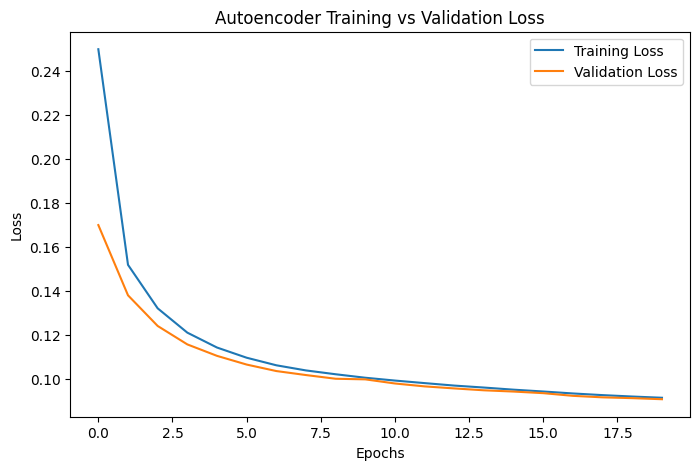

In [13]:

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Autoencoder Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

The training and validation loss curves show how the autoencoder learns during the training process. Initially, the loss values are high, but they decrease steadily as the number of epochs increases, indicating that the model is improving its reconstruction ability. Both training and validation losses follow a similar downward trend, which suggests that the model is learning effectively without significant overfitting. By the final epochs, the loss stabilizes around 0.09, showing that the model has converged. The close proximity of the two curves indicates that the model generalizes well to unseen test data. Overall, the graph demonstrates stable and consistent training performance of the autoencoder.

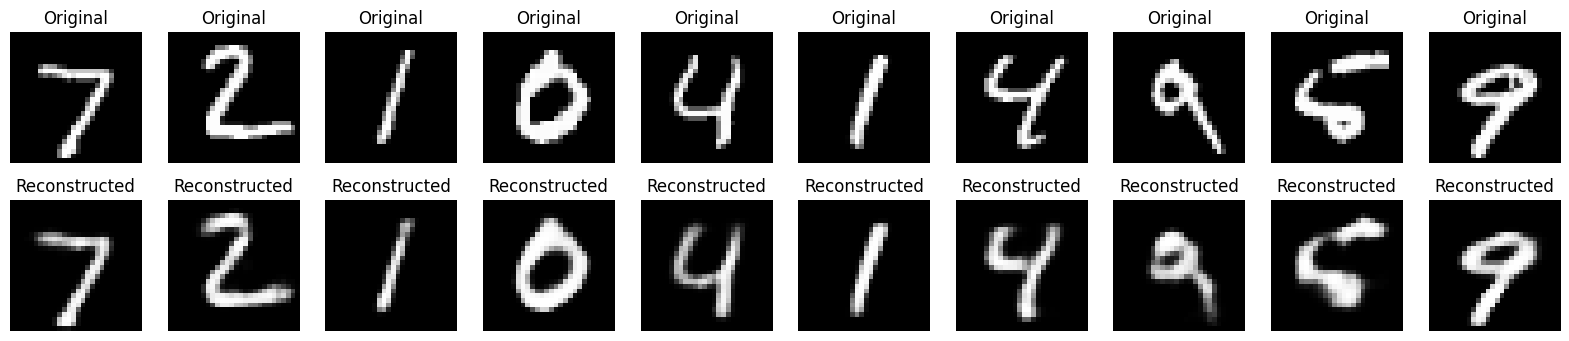

In [14]:
n = 10
plt.figure(figsize=(20,4))

for i in range(n):

    # Original images
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed images
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

The reconstructed images are very similar to the original MNIST digits, indicating that the autoencoder has successfully learned meaningful features of the input data. Although the reconstructed digits appear slightly smoother or blurred, the overall shapes and structures of the numbers are preserved. This minor loss of detail occurs because the model compresses the original 784-dimensional input into a smaller 32-dimensional latent representation. Despite this compression, the decoder is able to reconstruct recognizable digits with good accuracy. This demonstrates that the autoencoder effectively captures the essential patterns in the handwritten digit dataset.